# 18 - Naive Bayes

> 📘 **Instructor Curriculum**

### The story

You knock on ten doors in your colony. At every door you note down two things:
is there a **job** in this house, is there a **business** in this house - and
what do they park outside, a **car** or a **bike**?

```
                     10 houses in the colony
      ┌────────────────────────────────────────────────┐
      │    3 own a CAR                7 own a BIKE     │
      │   ┌───────────────┐        ┌────────────────┐  │
      │   │  job       1  │        │  job        2  │  │
      │   │  business  2  │        │  business   5  │  │
      │   └───────────────┘        └────────────────┘  │
      └────────────────────────────────────────────────┘
```

A new family moves in. You hear that they have a job and a business, but you
have not seen their vehicle. **Car or bike?**

Notice what you own: you counted *the other way round*. You know what car
owners do for a living. The new family gives you their work and asks for the
vehicle. Bayes theorem is the tool that turns your counting around.

### Bayes theorem

```
                   P(B|A) · P(A)
      P(A|B)  =  ──────────────────
                       P(B)
```

`P(A|B)` reads *"the chance of A, given that B has already happened."*

In machine-learning letters, `x` is what you know and `y` is what you want:

```
                   P(x|y) · P(y)
      P(y|x)  =  ──────────────────
                       P(x)
```

### Why "naive"

Real rows have many columns, not one. Naive Bayes handles that in the
laziest possible way - it takes each column on its own and multiplies:

```
                                P(x₁|y) · P(x₂|y) · … · P(xₙ|y) · P(y)
      P(y | x₁, x₂, …, xₙ)  =  ───────────────────────────────────────
                                    P(x₁) · P(x₂) · … · P(xₙ)
```

That multiplication assumes the columns do not affect each other. In real
data they usually do. Pretending they do not is the **naive** part of the
name, and it is the reason the model is so fast.

### Back to the colony

```
      P(car)  = 3/10          P(bike) = 7/10

                                 1     2     3
      P(car  | job, business) =  ─  ×  ─  ×  ──   =  0.066
                                 3     3     10

                                 2     5     7
      P(bike | job, business) =  ─  ×  ─  ×  ──   =  0.142
                                 7     7     10
```

Both answers sit on top of the same bottom line, `P(job) × P(business)`, so
you can cross it out and compare only the tops.

**0.142 beats 0.066 - the new family owns a bike.** Naive Bayes never tries to
be certain. It scores every class and hands you the winner.

Everything below is that same idea, with numbers instead of doors.

## Step 1 - Fourteen students, one column of marks

Now the same question shape, but on data you already know from
[16_Descison_Tree_Classfication.ipynb](16_Descison_Tree_Classfication.ipynb).

- `X` = the mark each student scored.
- `Y` = the `5me` column: **1 = watched the video lessons, 0 = did not.**

```
   Y = 1  (watched)     80  70  90  75  70  86  96  80  65        9 students
   Y = 0  (did not)     70  90  91  95  85                        5 students
```

The question: **a student scored 74. Did they watch the lessons?**

One thing to notice before the model starts. The mark is a *continuous*
number - 74, 74.5, 80.2, anything. You cannot count how many times "74"
happened, because in real marks it may never happen twice. That single fact
decides which Naive Bayes you are allowed to use, and Step 2 shows why.

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
X = np.array([80,70,90,75,70,86,96,80,65,70,90,91,95,85])
Y = np.array([1,1,1,1,1,1,1,1,1,0,0,0,0,0])

## Step 2 - GaussianNB: draw one bell curve per class

`X.reshape(-1, 1)` turns the flat list of 14 marks into a table of 14 rows and
1 column. sklearn always wants a table of rows, even when there is one column.
`-1` means *"work the row count out yourself."*

A continuous number cannot be counted, but it can be **described**. For each
group you only need two numbers - where the marks sit, and how spread out they
are:

```
   group                mean μ      standard deviation σ
   ─────────────────────────────────────────────────────
   Y = 1  (watched)      79.1              10.2
   Y = 0  (did not)      86.2               9.7
```

`fit()` computes exactly these four numbers and stops. That is the whole
training. It then places a bell curve on each group using the Gaussian
formula from your notes:

```
                     1                (x - μ)²
      P(x)  =  ────────────  ·  e^ -  ─────────
                √(2π σ²)                 2σ²
```

Feed the formula any mark and it returns *how normal that mark is for this
group*. That is the `P(x|y)` piece of Bayes theorem, now available for numbers
that were never in the training data.

Small honest note: your notes use σ = 10.2 and 9.7 (dividing by n-1). sklearn
divides by n and stores 9.6 and 8.7. Slightly different numbers, same
conclusion everywhere below.

In [36]:
x = X.reshape(-1,1)
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(x,Y)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[5.,9.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.36,0.64]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,9.823e-08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 1)","[[86.2 ], [79.11]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 1)","[[75.76], [92.77]]"


## Step 3 - A student scored 74

Put 74 into both bell curves:

```
      P(74 | watched)      =  0.034        ← taller
      P(74 | did not)      =  0.018
```

74 is close to the watchers' average of 79.1 and far below 86.2, so the first
curve is higher. Bayes then multiplies each one by how common the group is:

```
      watched   :  0.034 × 9/14  =  0.023      ★ winner
      did not   :  0.018 × 5/14  =  0.006
```

`classifier.predict([[74]])` returns `array([1])` - **watched the lessons**.

The double brackets are the same rule as `reshape`: predict expects a table of
rows, so one student is still a table with one row.

In [37]:
classifier.predict([[74]])

array([1])

## Step 4 - Now a student scored 99

Nothing about the model changed. Only the mark moved.

```
      P(99 | watched)  × 9/14  =  0.003
      P(99 | did not)  × 5/14  =  0.006      ★ winner
```

`array([0])` - **did not watch**. 99 sits far to the right of both averages,
but the non-watchers' curve is the one still alive out there.

Same model, same maths, opposite answer. Somewhere between 74 and 99 the two
curves cross, and that crossing point is the entire decision boundary. The
next cell draws it.

In [38]:
classifier.predict([[99]])

array([0])

### See it

The picture below is drawn from the model you just trained - `classifier.theta_`
holds the two means, `classifier.var_` the two variances. The small ticks along
the bottom are the 14 real students.

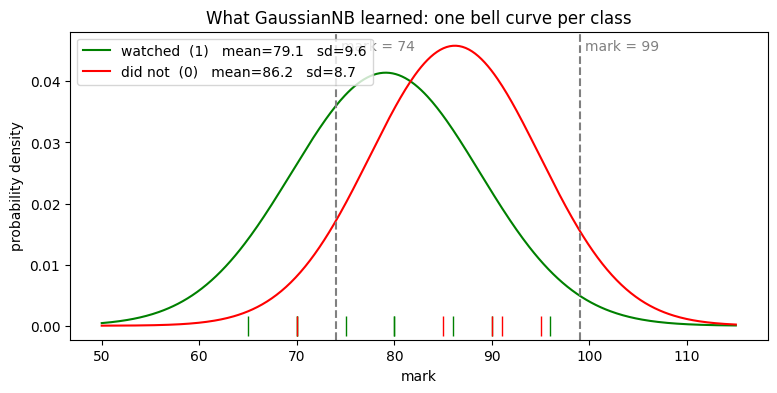

In [39]:
# the two bell curves GaussianNB learned from the 14 students
mu = classifier.theta_.ravel()           # mean of each class
sd = np.sqrt(classifier.var_.ravel())    # standard deviation of each class
grid = np.linspace(50, 115, 400)

plt.figure(figsize=(9, 4))
for label, colour, name in [(1, 'green', 'watched  (1)'), (0, 'red', 'did not  (0)')]:
    i = list(classifier.classes_).index(label)
    bell = 1 / np.sqrt(2 * np.pi * sd[i] ** 2) * np.exp(-(grid - mu[i]) ** 2 / (2 * sd[i] ** 2))
    plt.plot(grid, bell, color=colour, label=f"{name}   mean={mu[i]:.1f}   sd={sd[i]:.1f}")
    plt.plot(X[Y == label], np.zeros((Y == label).sum()), '|', color=colour, markersize=14)

for mark in [74, 99]:
    plt.axvline(mark, color='gray', linestyle='--')
    plt.text(mark + 0.5, 0.045, f"mark = {mark}", color='gray')

plt.title("What GaussianNB learned: one bell curve per class")
plt.xlabel("mark")
plt.ylabel("probability density")
plt.legend()
plt.show()

## Step 5 - A real dataset: iris

One column was the easy case. Iris gives you four:

| column | what it is |
| --- | --- |
| sepal length (cm) | a measurement |
| sepal width (cm) | a measurement |
| petal length (cm) | a measurement |
| petal width (cm) | a measurement |
| target | 0, 1 or 2 - the flower species |

All four are continuous centimetres, and there are three classes instead of
two. This is where the **naive** assumption starts working for its living:
petal length and petal width clearly move together in a real flower, and the
model is about to pretend they do not.

`load_iris()` returns a bunch object, not a table, so `pd.DataFrame(iris.data,
columns=iris.feature_names)` builds the table and the next cell glues the
answer column on.

In [40]:
from sklearn.datasets import load_iris
iris = load_iris()
table = pd.DataFrame(iris.data,columns=iris.feature_names)
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [41]:
table['target'] = iris.target
table.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 6 - Questions and answer

```
        x  (what you measure)                  y  (what you want)
   ┌──────┬──────┬──────┬──────┐              ┌────────┐
   │ s.len│ s.wid│ p.len│ p.wid│              │ target │
   ├──────┼──────┼──────┼──────┤              ├────────┤
   │  5.1 │  3.5 │  1.4 │  0.2 │              │   0    │
   │  ... │  ... │  ... │  ... │              │  ...   │
   └──────┴──────┴──────┴──────┘              └────────┘
```

`table.drop(['target'], axis='columns')` gives back a copy without the answer
column. `axis='columns'` is what tells drop to remove a column and not a row.

In [42]:
x = table.drop(['target'], axis='columns')
y = iris.target

## Step 7 - Hide 20% of the flowers

`train_test_split(x, y, test_size=0.20, random_state=0)` keeps 120 flowers for
training and locks 30 away for the exam.

`random_state=0` fixes which 30 are hidden. Change that number and you get a
different 30, and a slightly different score. Keep this in mind - it comes back
at the end of the notebook.

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

## Step 8 - Train

Same one-line `fit` as before, only bigger. GaussianNB now measures a mean and
a standard deviation **for every column inside every class**:

```
                sepal len   sepal wid   petal len   petal wid
   class 0       μ, σ        μ, σ        μ, σ        μ, σ
   class 1       μ, σ        μ, σ        μ, σ        μ, σ
   class 2       μ, σ        μ, σ        μ, σ        μ, σ
```

Twelve bell curves, plus three priors - how common each species was in the
training rows. That is the whole model. No loops, no gradient descent, one
pass over the data.

In [44]:
from sklearn.naive_bayes import GaussianNB
classifier1 = GaussianNB()
classifier1.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[39.,37.,44.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.33,0.31,0.37]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.159e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[5.02,3.4 ,1.46,0.24], [5.89,2.76,4.22,1.32], [6.64,2.99,5.57,2.03]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.13,0.14,0.02,0.01], [0.26,0.1 ,0.23,0.04], [0.39,0.11,0.29,0.06]]"


## Step 9 - Read the report card

For one test flower the model runs all twelve curves, multiplies the four
values inside each class by that class's prior, and keeps the biggest of the
three totals.

Put the two arrays side by side:

```
   y_pred  2 1 0 2 0 2 0 1 1 1 [1] 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0
   y_test  2 1 0 2 0 2 0 1 1 1 [2] 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0
                               ▲
                        one flower wrong
```

**29 right out of 30 = 0.967.** One borderline flower between species 1 and 2 -
the pair that genuinely overlaps in iris.

Remember this number. The next three cells feed the *same* data to the other
two Naive Bayes models, and this is the score they have to beat.

In [45]:
y_pred=classifier1.predict(X_test)
y_pred

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

In [46]:
y_test

array([2, 1, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 2, 1,
       0, 0, 2, 0, 0, 1, 1, 0])

## Step 10 - The first failure: MultinomialNB

MultinomialNB was built for **counts**. Its natural home is text: this email
contains "free" 3 times, "offer" 1 time, "invoice" 0 times. It asks
*"how many times did this thing happen?"*

Iris does not answer that question. `5.1` is not "sepal length happened 5.1
times" - it is a length. But nothing stops you from calling `fit`, so the model
quietly reads your centimetres as counts and trains anyway.

In [47]:
from sklearn.naive_bayes import MultinomialNB
classifier2 = MultinomialNB()
classifier2.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[39.,37.,44.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.12,-1.18,-1. ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 4)","[[195.8,132.7, 57. , 9.4], [217.8,102.2,156. , 49. ], [292.1,131.5,244.9, 89.4]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 4)","[[-0.71,-1.09,-1.93,-3.65], [-0.88,-1.63,-1.21,-2.36], [-0.96,-1.75,-1.13,-2.13]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"


In [48]:
classifier2.score(X_test,y_test)

0.5666666666666667

**0.567.** Seventeen flowers out of thirty.

It is not random - random over three classes would be near 0.33. Big petals do
produce big "counts", so some signal survives. But everything Gaussian used -
the average of each class, the spread around it - is thrown away. That is
0.967 down to 0.567 with the same data, the same split and the same one line
of code.

**The model did not break. It was handed the wrong shape of number.**

## Step 11 - The second failure: BernoulliNB

BernoulliNB expects **yes/no** columns - 1 or 0. Did the word appear at all?
Did the customer click or not?

To get there it first flattens every value with a threshold called `binarize`,
and the default threshold is `0.0`: anything above 0 becomes 1, the rest 0.

Now look at what that does to iris, where the smallest value in the whole
table is 0.1:

```
      raw row                        after binarize=0.0
      5.1  3.5  1.4  0.2      →       1   1   1   1
      4.9  3.0  1.4  0.2      →       1   1   1   1
      6.3  3.3  6.0  2.5      →       1   1   1   1
```

Every flower becomes the same row. The model has nothing left to tell them
apart, so it falls back on the biggest group in the training data - class 2,
44 rows of it - and answers `2` for all thirty test flowers.

Six of those thirty really are class 2. **6/30 = 0.2.** The score is not a bug,
it is arithmetic.

In [49]:
from sklearn.naive_bayes import BernoulliNB
classifier3 = BernoulliNB()
classifier3.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[39.,37.,44.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](3,)","[-1.12,-1.18,-1. ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 4)","[[39.,39.,39.,39.], [37.,37.,37.,37.], [44.,44.,44.,44.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](3, 4)","[[-0.02,-0.02,-0.02,-0.02], [-0.03,-0.03,-0.03,-0.03], [-0.02,-0.02,-0.02,-0.02]]"


In [50]:
classifier3.score(X_test,y_test)

0.2

## Step 12 - Change the data, not the model

Iris punished the wrong model. Now build data that punishes the *unprepared*
data, using `make_classification` - 5000 rows, 2 columns, 2 classes.

Two things about this data matter for the rest of the notebook:

- the values are spread around zero, so roughly **half of them are negative**;
- there is no `random_state`, so **every run makes a fresh dataset**. Your
  scores will move by a few points each time you run these cells. The story
  does not change.

In [51]:
from matplotlib import pyplot as plt

In [52]:
from sklearn.datasets import make_classification

In [53]:
x,y = make_classification(n_samples=5000, n_features=2, n_redundant=0)

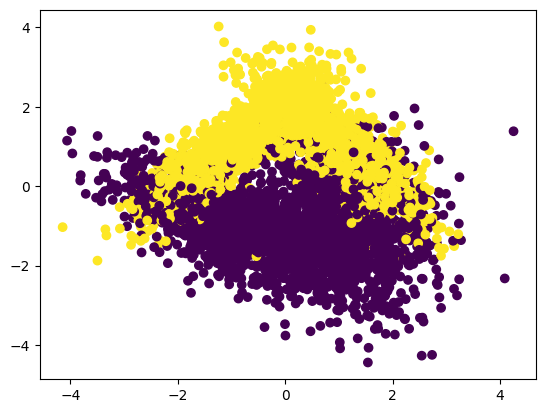

In [54]:
plt.scatter(x[:,0],x[:,1],c=y)

The scatter shows the two classes as two overlapping clouds, coloured by `y`.
Note the axes: both run from about -4 to +4. Remember that range.

Same 80/20 split as before, this time on the 5000 generated rows.

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

## Step 13 - Bernoulli, but with a threshold you chose

`BernoulliNB(binarize=0.5)` is the same model that scored 0.2 on iris. The only
change is where the cut sits.

Every value above 0.5 becomes 1, everything else 0. Two columns, two possible
values each, so the whole cloud collapses into four corners:

```
              feature 2
                  ▲
        (0,1)     │     (1,1)
                  │
      ─────────── 0.5 ───────────▶  feature 1
                  │
        (0,0)     │     (1,0)
                 0.5
```

Crude - but this time the corners actually line up with the two clouds, and the
score says **0.856**.

The threshold was doing all the work. `binarize=0.0` on iris gave 0.2;
`binarize=0.5` here gives 0.856. Same model, one number changed.

In [56]:
classifier2 = MultinomialNB()
classifier3 = BernoulliNB(binarize=0.5)

In [57]:
classifier3.fit(X_train, y_train)

,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.5
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[1991.,2009.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Log probability of each class (smoothed).","ndarray[float64](2,)","[-0.7 ,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 2)","[[ 786., 121.], [ 757.,1442.]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of features given a class, P(x_i|y).","ndarray[float64](2, 2)","[[-0.93,-2.79], [-0.98,-0.33]]"


In [58]:
classifier3.score(X_test, y_test)

0.817

## Step 14 - MultinomialNB refuses to start

This time there is no quiet wrong answer. There is a wall:

```
ValueError: Negative values in data passed to MultinomialNB (input X).
```

Your handwritten note says it in six words: *if there are -ve values, then
there is an error.*

And it is fair. MultinomialNB counts things. A count of `-1.2` does not exist -
no word appears minus one point two times. Around half the values in this
dataset are negative, so sklearn stops instead of pretending.

This is the friendliest failure in the notebook. The 0.567 on iris was silent;
this one tells you exactly what is wrong.

In [59]:
classifier2.fit(X_train, y_train)

ValueError: Negative values in data passed to MultinomialNB (input X).

### The crime scene

Everything in the red zone is a value MultinomialNB will not accept. The cell
also keeps a copy of the raw data as `x_before`, so we can compare after the
fix.

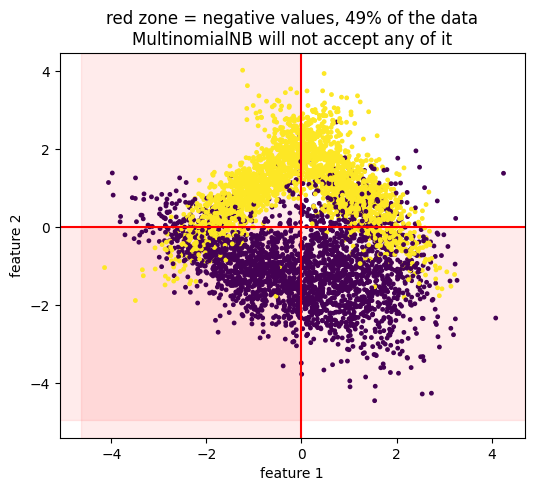

In [60]:
x_before = x.copy()      # keep the raw data, Step 15 compares against it

plt.figure(figsize=(6, 5))
plt.axvspan(x[:, 0].min() - 0.5, 0, color='red', alpha=0.08)
plt.axhspan(x[:, 1].min() - 0.5, 0, color='red', alpha=0.08)
plt.scatter(x[:, 0], x[:, 1], c=y, s=6)
plt.axvline(0, color='red')
plt.axhline(0, color='red')
plt.title("red zone = negative values, %.0f%% of the data\nMultinomialNB will not accept any of it"
          % (100 * (x < 0).mean()))
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()

## Step 15 - Pre-processing: give the model numbers it can accept

`MinMaxScaler` squeezes every column into the range 0 to 1:

```
                     x  -  min
      x_scaled  =  ─────────────
                    max  -  min
```

The smallest value in a column becomes 0, the largest becomes 1, and everything
else lands in between **in the same order**. No point overtakes another, no
cloud changes shape - only the ruler changes.

```
      before      -4.0 ──────────── 0 ──────────── +4.0
                    ▲ negatives ▲
      after         0.0 ─────────────────────────── 1.0
                    no negatives left
```

`fit_transform` does two jobs: `fit` finds the min and max of each column,
`transform` applies the formula. And that is the whole repair.

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [30]:
scalar = MinMaxScaler()
x = scalar.fit_transform(x)

### Before and after

Same 5000 points, twice. Only the numbers on the axes moved.

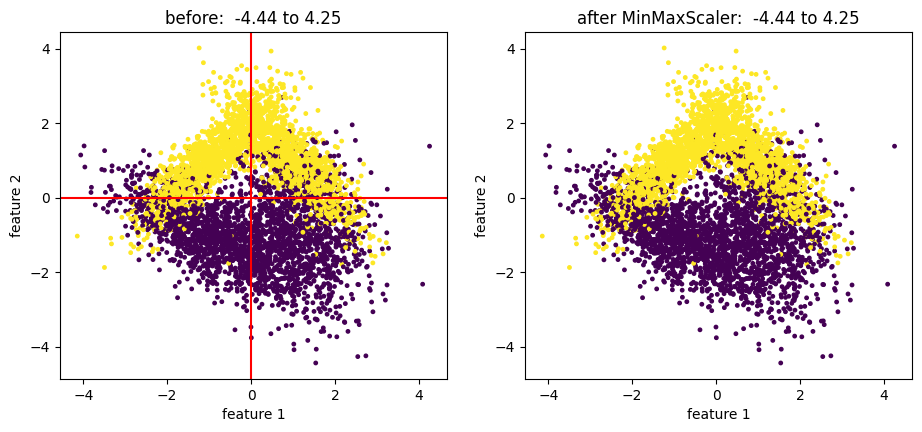

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].scatter(x_before[:, 0], x_before[:, 1], c=y, s=6)
ax[0].axvline(0, color='red')
ax[0].axhline(0, color='red')
ax[0].set_title("before:  %.2f to %.2f" % (x_before.min(), x_before.max()))

ax[1].scatter(x[:, 0], x[:, 1], c=y, s=6)
ax[1].set_title("after MinMaxScaler:  %.2f to %.2f" % (x.min(), x.max()))

for a in ax:
    a.set_xlabel("feature 1")
    a.set_ylabel("feature 2")
plt.show()

## Step 16 - Split again

The split has to be redone, because `x` is a different array now. Splitting
before scaling and then scaling both halves separately would leak information
from the test set into training - the reason [03_preprocessing.ipynb](03_preprocessing.ipynb)
keeps hammering on `Pipeline`.

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state = 0)

In [63]:
classifier2 = MultinomialNB()

## Step 17 - The same model, now it runs

No error. `MultinomialNB` fits, and scores **0.752**.

That is the point of the whole notebook, in two cells:

```
      raw data          →   ValueError, no model at all
      MinMaxScaler      →   0.752
```

Now read the number honestly. 0.752 is below the 0.856 that Bernoulli got on
this same data. Pre-processing removed the **crash**, it did not make
MultinomialNB the right model - these are still continuous measurements, not
counts, and your own handwritten rule says continuous data belongs to
GaussianNB.

**Pre-processing gets your data through the door. Choosing the model is a
separate job.**

In [64]:
classifier2.fit(X_train, y_train)

ValueError: Negative values in data passed to MultinomialNB (input X).

In [65]:
classifier2.score(X_test, y_test)

AttributeError: 'MultinomialNB' object has no attribute 'feature_log_prob_'

## Which Naive Bayes do I pick?

Straight from your handwritten page:

```
                    is the feature a continuous number?
                                   │
                ┌────── yes ───────┴────── no ───────┐
                ▼                                    ▼
           GaussianNB                    is it a count or a frequency?
      bell curve per class                          │
      iris: 0.967                     ┌──── yes ────┴──── no (0/1) ────┐
                                      ▼                                ▼
                               MultinomialNB                     BernoulliNB
                          no negative values allowed        cuts at `binarize=`
                          scale them first                  default cut is 0.0
```

## Can we increase the model's accuracy?

Your notes list four levers. Every one of them already happened in this
notebook:

| # | Lever | What it did here |
| --- | --- | --- |
| 1 | **Pre-processing** | MinMaxScaler turned a `ValueError` into 0.752 |
| 2 | **Random state / split** | no seed on `make_classification`, so the score moves every run |
| 3 | **Algorithm selection** | same iris data: 0.967, 0.567, 0.2 |
| 4 | **Hyperparameter tuning** | `binarize` 0.0 → 0.2, `binarize` 0.5 → 0.856 |

And the line under lever 1 in your notes is the summary of the entire notebook:

```
      data          algorithm        result
      ──────────────────────────────────────
      wrong         wrong            wrong
      wrong         correct          wrong
      correct       correct          proper
```

Correct data alone is not enough. Correct algorithm alone is not enough. You
need both, and this notebook failed once in each way before getting both right.

**If you remember only one thing:** Naive Bayes scores every class with
`P(x|y) × P(y)` and returns the winner - the maths never fails. What fails is
handing a model a shape of number it was not built for: centimetres to a
counter, positives-only to negative data, a threshold in the wrong place.